# Naive Persistence Baseline

## Description

The naive persistence forecast predicts the geomagnetic field $h$ hours from now as identical to its current value:

$$\hat{D}_{st}(t+h) = D_{st}(t)$$

No solar wind parameters, neutron monitor data, or learned relationships are used. Persistence serves as the **absolute lower bound** — any model that fails to outperform it at a given horizon provides no predictive value beyond the current observation.

Persistence performance degrades systematically with horizon. At h=1h the geomagnetic field changes little, making persistence a strong baseline. At h=21h the storm state may have evolved substantially, making it increasingly uninformative. The rate of this degradation defines the difficulty of the forecasting problem at each horizon and sets the reference level for all subsequent models.

All models are evaluated against this baseline via:
- **MASE** (Mean Absolute Scaled Error) — a model with MASE < 1 outperforms persistence; MASE > 1 means the model is operationally useless at that horizon regardless of absolute RMSE
- **Diebold-Mariano test** — statistical significance of the improvement over persistence

**Depends on:** `data/processed/feat_split.parquet`, `models/split_masks.pkl`, `models/context_constants.pkl`

## Mathematical Formulation

**Persistence forecast** at horizon $h$ for observation at time $t$:

$$\hat{D}_{st}(t+h) = D_{st}(t)$$

The forecast error is:

$$e_t^{(h)} = D_{st}(t+h) - \hat{D}_{st}(t+h) = D_{st}(t+h) - D_{st}(t)$$

This is simply the $h$-step difference of the $D_{st}$ series. The error grows with $h$ because the autocorrelation of $D_{st}$ decays — from PACF lag1 = 0.978 at h=1h toward zero at longer horizons.

**RMSE** at horizon $h$ over evaluation set $\mathcal{T}$:

$$\text{RMSE}^{(h)} = \sqrt{\frac{1}{|\mathcal{T}|} \sum_{t \in \mathcal{T}} \left( D_{st}(t+h) - D_{st}(t) \right)^2}$$

**Storm RMSE** — restricted to storm hours ($D_{st}(t+h) < -50$ nT):

$$\text{StormRMSE}^{(h)} = \sqrt{\frac{1}{|\mathcal{T}_s|} \sum_{t \in \mathcal{T}_s} \left( D_{st}(t+h) - D_{st}(t) \right)^2}$$

where $\mathcal{T}_s = \{t \in \mathcal{T} : D_{st}(t+h) < -50 \text{ nT}\}$.

**MASE** (Mean Absolute Scaled Error) [HYN06] — normalises MAE by the in-sample one-step persistence error on the training set:

$$\text{MASE}^{(h)} = \frac{\frac{1}{|\mathcal{T}|} \sum_{t \in \mathcal{T}} |e_t^{(h)}|}{\frac{1}{|\text{train}|-1} \sum_{t \in \text{train}} |D_{st}(t+1) - D_{st}(t)|}$$

The denominator is the mean absolute one-step difference on the training set — a scale-free normalisation that is independent of the forecast horizon. For persistence at horizon $h > 1$, MASE > 1 by construction, confirming degradation with horizon.

**Diebold-Mariano test** [DM95] — tests whether the difference in forecast errors between two models is statistically significant:

$$DM = \frac{\bar{d}}{\sqrt{\hat{V}(\bar{d})}} \sim \mathcal{N}(0,1)$$

where $\bar{d} = \frac{1}{|\mathcal{T}|}\sum_{t \in \mathcal{T}} (e_{1,t}^2 - e_{2,t}^2)$ is the mean difference in squared errors between model 1 (persistence) and model 2 (candidate). A significant negative $DM$ statistic ($p < 0.05$) indicates that the candidate model produces smaller errors than persistence.

The variance $\hat{V}(\bar{d})$ is estimated via a Newey-West HAC estimator with bandwidth $h-1$, which accounts for serial correlation in the loss differential series introduced by $h$-step-ahead overlapping forecast errors [DM95].

In [1]:
# ── Cell 1: Imports & Load ────────────────────────────────────────────────
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import joblib
import mlflow
import mlflow.sklearn

import matplotlib.pyplot as plt

from src.estimators import NaivePersistence
from src.evaluate   import compute_metrics

In [2]:
import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
mlflow.set_tracking_uri("../mlruns")
mlflow.set_experiment('cosmic_ray_storm_prediction')

<Experiment: artifact_location='file:///C:/Temp/python-start/work/PracticalProjects/cosmic-ray-storm/notebooks/../mlruns/292621262165687921', creation_time=1782395978156, effective_trace_archival_retention=None, experiment_id='292621262165687921', last_update_time=1782395978156, lifecycle_stage='active', name='cosmic_ray_storm_prediction', tags={}, trace_location=None, workspace='default'>

In [3]:
# ── Load artifacts ────────────────────────────────────────────────────────
feat  = pd.read_parquet('../data/processed/feat_split.parquet')
masks = joblib.load('../models/split_masks.pkl')
ctx   = joblib.load('../models/context_constants.pkl')

K_HORIZONS = ctx['K_HORIZONS']   # [1, 3, 7, 12, 21]
STORM_THR  = ctx['STORM_THR']    # -50

print(f'feat shape  : {feat.shape}')
print(f'K_HORIZONS  : {K_HORIZONS}')
print(f'STORM_THR   : {STORM_THR} nT')

feat shape  : (364728, 73)
K_HORIZONS  : [1, 3, 7, 12, 21]
STORM_THR   : -50 nT


In [4]:
# ── Cell 2: Prepare splits ────────────────────────────────────────────────
#
# Evaluation is performed on two validation segments:
#   val_main  (2009-01-01 → 2014-12-31) — routine multi-horizon evaluation
#   val_storm (2003-10-15 → 2003-12-15) — dedicated extreme storm evaluation
#             (Halloween 2003 + November 2003, Dst = -422 nT)
#
# Both segments are evaluated separately. val_storm metrics characterise
# baseline performance under extreme conditions and serve as the reference
# for all subsequent models on that segment.
#
# Purge zones (21h on each side of split boundaries) are encoded in
# split_masks.pkl and excluded via the finite-value check in compute_metrics().
#
# y_train is Train_1 | Train_2 Dst values (purge zones excluded),
# used solely to compute the MASE denominator.

train_mask      = masks['train']       # Train_1 | Train_2, purge zones excluded
val_main_mask   = masks['val_main']    # 2009-01-01 → 2014-12-31
val_storm_mask  = masks['val_storm']   # 2003-10-15 → 2003-12-15

EVAL_SEGMENTS = {
    'val_main' : val_main_mask,
    'val_storm': val_storm_mask,
}

y_train = feat.loc[train_mask, 'dst'].copy()

print(f'Train rows      : {train_mask.sum():,}')
print(f'Val_main rows   : {val_main_mask.sum():,}')
print(f'Val_storm rows  : {val_storm_mask.sum():,}')
print(f'y_train NaN     : {y_train.isna().sum()}')


Train rows      : 121,185
Val_main rows   : 52,542
Val_storm rows  : 1,446
y_train NaN     : 0


In [5]:
# ── Cell 3: Run persistence per horizon + MLflow logging ─────────────────
#
# NaivePersistence.predict(X) returns X['dst'] — the current Dst value.
# For horizon h, y_true is dst_target_{h}h (the Dst value h hours ahead).
#
# DM variance = 0 by construction (persistence vs itself) — RuntimeWarning
# is expected and NaN is handled explicitly before MLflow logging.
#
# Structure: one parent run per segment, one child run per horizon.

import tempfile, os

def _safe_float(v, fallback=0.0):
    """Convert to float; replace NaN/inf with fallback for MLflow logging."""
    try:
        f = float(v)
        return fallback if (np.isnan(f) or np.isinf(f)) else f
    except (TypeError, ValueError):
        return fallback

model       = NaivePersistence(dst_col='dst')
all_metrics = {}   # {segment: {horizon: metrics_dict}}


for seg_name, seg_mask in EVAL_SEGMENTS.items():
    all_metrics[seg_name] = {}
    print(f'\n── Segment: {seg_name} ──────────────────────────────────────')

    with mlflow.start_run(run_name=f'naive_persistence_{seg_name}') as parent_run:
        mlflow.set_tag('model_type',     'baseline')
        mlflow.set_tag('evaluation_set', seg_name)

        for h in K_HORIZONS:
            target_col = f'dst_target_{h}h'

            X_seg  = feat.loc[seg_mask].copy()
            y_true = feat.loc[seg_mask, target_col].copy()

            y_pred    = model.predict(X_seg)   # ŷ(t+h) = Dst(t)
            y_persist = y_pred.copy()           # DM variance = 0 by construction

            metrics = compute_metrics(
                y_true    = y_true,
                y_pred    = y_pred,
                y_train   = y_train,
                y_persist = y_persist,
                storm_thr = STORM_THR,
                horizon   = h,
            )
            all_metrics[seg_name][h] = metrics

            with mlflow.start_run(
                run_name=f'naive_persistence_{seg_name}_h{h}', nested=True
            ):
                mlflow.log_params({
                    'horizon'   : h,
                    'storm_thr' : STORM_THR,
                    'n_eval'    : metrics['n_eval'],
                    'n_storm'   : metrics['n_storm'],
                })
                mlflow.log_metrics({
                    'rmse'      : _safe_float(metrics['rmse']),
                    'storm_rmse': _safe_float(metrics['storm_rmse']),
                    'mase'      : _safe_float(metrics['mase']),
                    'dm_stat'   : _safe_float(metrics['dm_stat'],   fallback=0.0),
                    'dm_pvalue' : _safe_float(metrics['dm_pvalue'], fallback=1.0),
                })

                # Save metrics as JSON artifact — use tempfile for cross-platform
                tmp_dir      = tempfile.gettempdir()
                metrics_path = os.path.join(
                    tmp_dir, f'naive_persistence_{seg_name}_h{h}.json'
                )
                with open(metrics_path, 'w') as f:
                    json.dump(
                        {k: (float(v) if not isinstance(v, int) else v)
                         for k, v in metrics.items()},
                        f, indent=2,
                    )
                mlflow.log_artifact(metrics_path)

            print(f'  h={h:>2}h | RMSE={metrics["rmse"]:6.2f} | '
                  f'StormRMSE={metrics["storm_rmse"]:6.2f} | '
                  f'MASE={metrics["mase"]:5.3f} | '
                  f'n_storm={metrics["n_storm"]}')

        print(f'  parent run id: {parent_run.info.run_id}')



── Segment: val_main ──────────────────────────────────────


C:\Temp\python-start\work\PracticalProjects\cosmic-ray-storm\notebooks\..\src\evaluate.py:337: RuntimeWarning: diebold_mariano: non-positive variance estimate. Returning NaN.
  dm_stat, dm_pvalue = diebold_mariano(


  h= 1h | RMSE=  3.55 | StormRMSE=  9.19 | MASE=0.814 | n_storm=1165
  h= 3h | RMSE=  7.37 | StormRMSE= 22.34 | MASE=1.712 | n_storm=1165
  h= 7h | RMSE= 10.90 | StormRMSE= 38.85 | MASE=2.481 | n_storm=1165
  h=12h | RMSE= 13.27 | StormRMSE= 50.46 | MASE=2.992 | n_storm=1165
  h=21h | RMSE= 15.44 | StormRMSE= 60.25 | MASE=3.494 | n_storm=1165
  parent run id: 7b642c20b9c94e6fa81737980a9a578a

── Segment: val_storm ──────────────────────────────────────
  h= 1h | RMSE= 10.04 | StormRMSE= 24.41 | MASE=1.753 | n_storm=191
  h= 3h | RMSE= 22.79 | StormRMSE= 58.54 | MASE=3.637 | n_storm=191
  h= 7h | RMSE= 38.76 | StormRMSE=102.29 | MASE=5.800 | n_storm=190
  h=12h | RMSE= 47.71 | StormRMSE=126.01 | MASE=7.326 | n_storm=190
  h=21h | RMSE= 54.42 | StormRMSE=142.70 | MASE=8.625 | n_storm=190
  parent run id: bf56699bb117456987009dac4cc71387


> **Observations — Naive Persistence Baseline:**
> - Persistence degrades monotonically with horizon on both evaluation segments, consistent with decaying $D_{st}$ autocorrelation (PACF lag1 = 0.978). RMSE increases from 3.55 nT at h=1h to 15.44 nT at h=21h on val_main; Storm RMSE increases from 9.19 nT to 60.25 nT over the same range.
> - **MASE < 1 at h=1h (val_main, MASE=0.814):** one-step persistence outperforms the mean absolute one-step training error — expected given the near-unit autocorrelation of $D_{st}$ at lag 1. At h≥3h, MASE exceeds 1.0 and grows monotonically, reaching MASE=3.494 at h=21h, confirming that multi-step persistence provides progressively less information than the training-set baseline.
> - **val_storm (Halloween 2003, $D_{st}$ = −422 nT):** all metrics are substantially higher than val_main at every horizon. At h=7h, Storm RMSE = 102.29 nT and MASE = 5.800 — persistence is nearly 6× worse than the one-step training baseline. This reflects rapid $D_{st}$ evolution during superstorms, where the current value is a poor substitute for the future state.
> - **Reference thresholds for subsequent models:** Storm RMSE at h=7h on val_main (38.85 nT) and val_storm (102.29 nT) are the primary operational targets. Any model with MASE > 1 at a given horizon on val_main provides no predictive value over persistence at that horizon, regardless of absolute RMSE.
> - DM statistic = 0, p-value = 1.0 by construction — persistence evaluated against itself. These values serve as a wiring sanity check for `compute_metrics()` and carry no inferential content.

In [6]:
# ── Cell 4: Results tables ────────────────────────────────────────────────

for seg_name, seg_metrics in all_metrics.items():
    rows = []
    for h, m in seg_metrics.items():
        rows.append({
            'Horizon (h)': h,
            'RMSE'       : round(m['rmse'],        2),
            'Storm RMSE' : round(m['storm_rmse'],  2),
            'MASE'       : round(m['mase'],         3),
            'n_eval'     : m['n_eval'],
            'n_storm'    : m['n_storm'],
        })
    df = pd.DataFrame(rows).set_index('Horizon (h)')
    print(f'Naive Persistence — {seg_name}')
    print('=' * 55)
    print(df.to_string())
    print()

print('Note: DM stat = 0, p-value = 1.0 by construction — sanity check only.')


Naive Persistence — val_main
              RMSE  Storm RMSE   MASE  n_eval  n_storm
Horizon (h)                                           
1             3.55        9.19  0.814   52542     1165
3             7.37       22.34  1.712   52542     1165
7            10.90       38.85  2.481   52542     1165
12           13.27       50.46  2.992   52542     1165
21           15.44       60.25  3.494   52542     1165

Naive Persistence — val_storm
              RMSE  Storm RMSE   MASE  n_eval  n_storm
Horizon (h)                                           
1            10.04       24.41  1.753    1446      191
3            22.79       58.54  3.637    1446      191
7            38.76      102.29  5.800    1446      190
12           47.71      126.01  7.326    1446      190
21           54.42      142.70  8.625    1446      190

Note: DM stat = 0, p-value = 1.0 by construction — sanity check only.


> **Observations — Naive Persistence Results Tables:**
> - **n_storm consistency:** n_storm = 1,165 across all horizons on val_main and 191/190 on val_storm. The one-row drop at h≥7h on val_storm is a boundary effect — the last 6 rows of the segment have no valid `dst_target_{h}h` target due to the purge zone.
> - **Storm fraction:** 1,165 / 52,542 = 2.22% storm hours on val_main vs 191 / 1,446 = 13.2% on val_storm — confirming that val_storm is a storm-dense segment by design and not representative of the general distribution.
> - **Storm RMSE / RMSE ratio:** on val_main the ratio grows from 2.59× at h=1h to 3.90× at h=21h — storm hours are substantially harder than quiet hours at every horizon, and the gap widens with horizon. On val_storm the ratio is 2.43×–2.62×, narrower because the entire segment is storm-dominated and RMSE itself is already elevated.
> - **MASE scaling between segments:** at h=7h, MASE = 2.481 on val_main vs 5.800 on val_storm — val_storm is 2.34× harder for persistence at this horizon. This ratio provides a rough upper bound on the difficulty premium that any model will face on extreme events relative to routine evaluation.

In [7]:
# ── Cell 5: Save artifacts ────────────────────────────────────────────────

joblib.dump(all_metrics, '../models/naive_persistence_metrics.pkl')
print('Saved: ../models/naive_persistence_metrics.pkl')

# Save per-segment CSVs for easy inspection
for seg_name, seg_metrics in all_metrics.items():
    rows = []
    for h, m in seg_metrics.items():
        rows.append({'horizon': h, **m})
    pd.DataFrame(rows).set_index('horizon').to_csv(
        f'../models/naive_persistence_metrics_{seg_name}.csv'
    )
    print(f'Saved: ../models/naive_persistence_metrics_{seg_name}.csv')


Saved: ../models/naive_persistence_metrics.pkl
Saved: ../models/naive_persistence_metrics_val_main.csv
Saved: ../models/naive_persistence_metrics_val_storm.csv


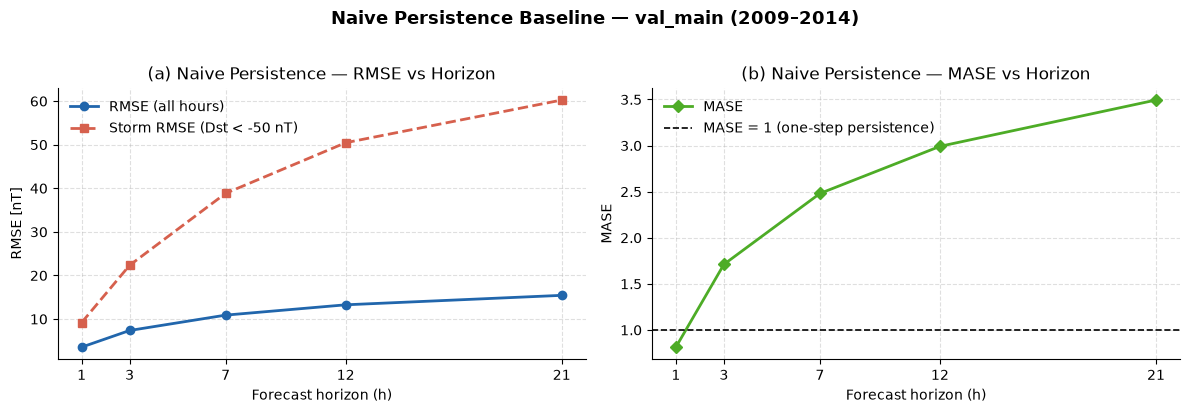

Saved: ../images/fig_naive_persistence_metrics.png


In [8]:
# ── Cell 6: Visualisation (val_main) ─────────────────────────────────────
#
# Two-panel figure based on val_main metrics.
# val_storm is a 2-month window — its horizon profile is reported
# in the results table above but not plotted separately here.
#
# Panel (a): RMSE and Storm RMSE vs horizon.
# Panel (b): MASE vs horizon with reference line at 1.0.
#
# Storm RMSE is the primary operational metric throughout this project.
# MASE > 1 at h > 1 is expected for persistence and quantifies how much
# worse multi-step persistence is compared to one-step persistence [HYN06].

vm = all_metrics['val_main']
horizons   = list(vm.keys())
rmse_vals  = [vm[h]['rmse']       for h in horizons]
srmse_vals = [vm[h]['storm_rmse'] for h in horizons]
mase_vals  = [vm[h]['mase']       for h in horizons]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(horizons, rmse_vals,  'o-',  color='#2166ac', lw=2,
             label='RMSE (all hours)')
axes[0].plot(horizons, srmse_vals, 's--', color='#d6604d', lw=2,
             label='Storm RMSE (Dst < -50 nT)')
axes[0].set_xlabel('Forecast horizon (h)')
axes[0].set_ylabel('RMSE [nT]')
axes[0].set_title('(a) Naive Persistence — RMSE vs Horizon')
axes[0].set_xticks(horizons)
axes[0].legend(frameon=False)
axes[0].grid(True, linestyle='--', alpha=0.4)
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(horizons, mase_vals, 'D-', color='#4dac26', lw=2, label='MASE')
axes[1].axhline(1.0, color='black', lw=1.2, linestyle='--',
                label='MASE = 1 (one-step persistence)')
axes[1].set_xlabel('Forecast horizon (h)')
axes[1].set_ylabel('MASE')
axes[1].set_title('(b) Naive Persistence — MASE vs Horizon')
axes[1].set_xticks(horizons)
axes[1].legend(frameon=False)
axes[1].grid(True, linestyle='--', alpha=0.4)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle(
    'Naive Persistence Baseline — val_main (2009–2014)',
    fontsize=13, fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.savefig('../images/fig_naive_persistence_metrics.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../images/fig_naive_persistence_metrics.png')


> **Observations — Naive Persistence Baseline (Figure):**
> - Both panels show monotonic degradation with horizon, confirming that $D_{st}$ predictability from the current state alone decreases systematically as the forecast window extends.
> - **Panel (a):** Storm RMSE (dashed red) grows substantially faster than overall RMSE (solid blue) — the gap widens from 5.64 nT at h=1h to 44.81 nT at h=21h. This divergence reflects that storm hours exhibit rapid $D_{st}$ evolution that persistence cannot track, while quiet hours remain near-stationary and dominate the overall RMSE.
> - **Panel (b):** MASE crosses 1.0 between h=1h and h=3h — the inflection point where multi-step persistence becomes worse than the one-step training baseline. The concave shape indicates diminishing marginal difficulty: the largest MASE increment occurs between h=1h and h=3h (Δ=0.898), with smaller increments at longer horizons (h=12h→21h: Δ=0.502).
> - The h=7h operating point (Storm RMSE = 38.85 nT, MASE = 2.481) lies on the steepest part of both curves — modest horizon reductions yield large accuracy gains, making it the most informative single horizon for model comparison.